# DBSCAN sur le Dataset Mall Customers

**Algorithme :** DBSCAN (Density-Based Spatial Clustering of Applications with Noise)  
**Dataset :** Mall Customers (Kaggle) - segmentation client par revenu et score de dépense  
**Objectif :** Identifier des clusters de clients selon leur comportement d'achat, et détecter les outliers naturellement

In [19]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

  MALL CUSTOMERS - APERCU GENERAL
  Samples      : 200
  Features     : 5
  Colonnes     : ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
  Valeurs NaN  : 0

  DISTRIBUTION DU GENRE
  Female : 112 clients
  Male : 88 clients

  STATISTIQUES DESCRIPTIVES
          Age  Annual Income (k$)  Spending Score (1-100)
count  200.00              200.00                  200.00
mean    38.85               60.56                   50.20
std     13.97               26.26                   25.82
min     18.00               15.00                    1.00
25%     28.75               41.50                   34.75
50%     36.00               61.50                   50.00
75%     49.00               78.00                   73.00
max     70.00              137.00                   99.00


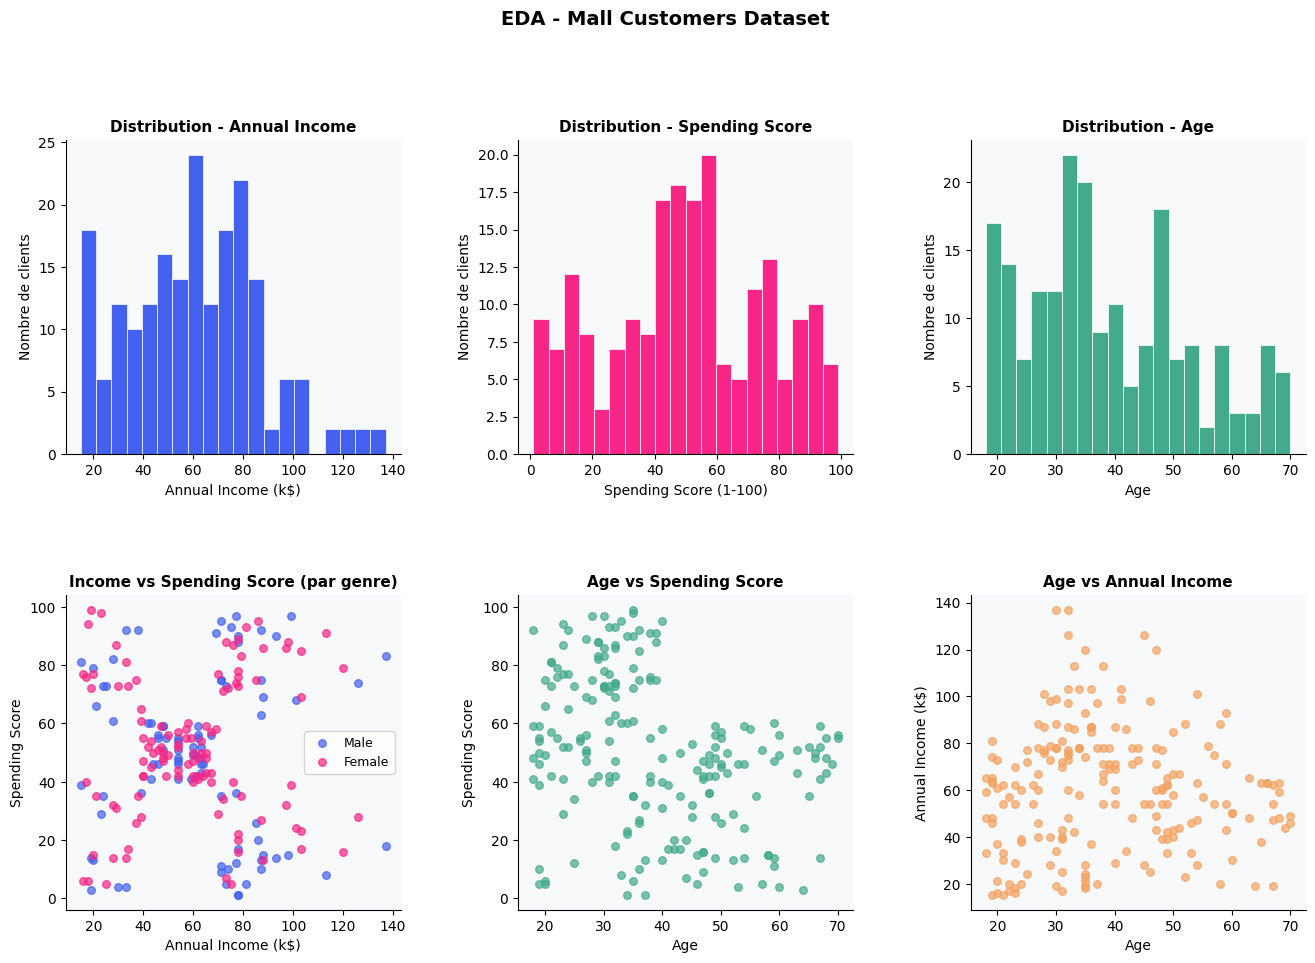

In [20]:
# Chargement 
path = kagglehub.dataset_download('vjchoudhary7/customer-segmentation-tutorial-in-python')
df = pd.read_csv(f'{path}/Mall_Customers.csv')

print('=' * 55)
print('  MALL CUSTOMERS - APERCU GENERAL')
print('=' * 55)
print(f'  Samples      : {df.shape[0]}')
print(f'  Features     : {df.shape[1]}')
print(f'  Colonnes     : {df.columns.tolist()}')
print(f'  Valeurs NaN  : {df.isna().sum().sum()}')

print('\n' + '=' * 55)
print('  DISTRIBUTION DU GENRE')
print('=' * 55)
for genre, count in df['Gender'].value_counts().items():
    print(f'  {genre} : {count} clients')

print('\n' + '=' * 55)
print('  STATISTIQUES DESCRIPTIVES')
print('=' * 55)
print(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].describe().round(2).to_string())

# Features retenues
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Palette
blue = '#4361ee'
pink = '#f72585'

# Subplot 1 : Distribution Annual Income
ax0 = fig.add_subplot(gs[0, 0])
ax0.hist(df['Annual Income (k$)'], bins=20, color=blue, edgecolor='white', linewidth=0.5)
ax0.set_title('Distribution - Annual Income', fontsize=11, fontweight='bold')
ax0.set_xlabel('Annual Income (k$)')
ax0.set_ylabel('Nombre de clients')
ax0.set_facecolor('#f8f9fa')
ax0.spines[['top', 'right']].set_visible(False)

# Subplot 2 : Distribution Spending Score
ax1 = fig.add_subplot(gs[0, 1])
ax1.hist(df['Spending Score (1-100)'], bins=20, color=pink, edgecolor='white', linewidth=0.5)
ax1.set_title('Distribution - Spending Score', fontsize=11, fontweight='bold')
ax1.set_xlabel('Spending Score (1-100)')
ax1.set_ylabel('Nombre de clients')
ax1.set_facecolor('#f8f9fa')
ax1.spines[['top', 'right']].set_visible(False)

# Subplot 3 : Distribution Age
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(df['Age'], bins=20, color='#43aa8b', edgecolor='white', linewidth=0.5)
ax2.set_title('Distribution - Age', fontsize=11, fontweight='bold')
ax2.set_xlabel('Age')
ax2.set_ylabel('Nombre de clients')
ax2.set_facecolor('#f8f9fa')
ax2.spines[['top', 'right']].set_visible(False)

# Subplot 4 : Scatter Income vs Spending (non clusterisé)
ax3 = fig.add_subplot(gs[1, 0])
male_mask   = df['Gender'] == 'Male'
female_mask = df['Gender'] == 'Female'
ax3.scatter(X[male_mask, 0],   X[male_mask, 1],   color=blue, s=30, alpha=0.7, label='Male')
ax3.scatter(X[female_mask, 0], X[female_mask, 1], color=pink, s=30, alpha=0.7, label='Female')
ax3.set_title('Income vs Spending Score (par genre)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Annual Income (k$)')
ax3.set_ylabel('Spending Score')
ax3.legend(fontsize=9)
ax3.set_facecolor('#f8f9fa')
ax3.spines[['top', 'right']].set_visible(False)

# Subplot 5 : Age vs Spending Score
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(df['Age'], df['Spending Score (1-100)'], color='#43aa8b', s=30, alpha=0.7)
ax4.set_title('Age vs Spending Score', fontsize=11, fontweight='bold')
ax4.set_xlabel('Age')
ax4.set_ylabel('Spending Score')
ax4.set_facecolor('#f8f9fa')
ax4.spines[['top', 'right']].set_visible(False)

# Subplot 6 : Age vs Annual Income
ax5 = fig.add_subplot(gs[1, 2])
ax5.scatter(df['Age'], df['Annual Income (k$)'], color='#f4a261', s=30, alpha=0.7)
ax5.set_title('Age vs Annual Income', fontsize=11, fontweight='bold')
ax5.set_xlabel('Age')
ax5.set_ylabel('Annual Income (k$)')
ax5.set_facecolor('#f8f9fa')
ax5.spines[['top', 'right']].set_visible(False)

fig.suptitle('EDA - Mall Customers Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.show();

In [21]:
# Train / validation / test split
feature_cols = ['Annual Income (k$)', 'Spending Score (1-100)']
df_all = df.copy()

df_train, df_temp = train_test_split(df_all, test_size=0.30, random_state=42, shuffle=True)
df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=42, shuffle=True)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_trainval = pd.concat([df_train, df_val], ignore_index=True)

X_train = df_train[feature_cols].values
X_val = df_val[feature_cols].values
X_test = df_test[feature_cols].values
X_trainval = df_trainval[feature_cols].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

total_n = len(df_all)
print('=' * 55)
print('  PREPROCESSING + SPLIT 70/15/15')
print('=' * 55)
print(f'  Train set      : {len(df_train):3d} rows ({len(df_train) / total_n:.0%})')
print(f'  Validation set : {len(df_val):3d} rows ({len(df_val) / total_n:.0%})')
print(f'  Test set       : {len(df_test):3d} rows ({len(df_test) / total_n:.0%})')
print(f'  Features       : {feature_cols}')
print('  Normalisation  : StandardScaler fitted on train only')
print(f'  X_train shape  : {X_train_scaled.shape}')
print(f'  X_val shape    : {X_val_scaled.shape}')
print(f'  X_test shape   : {X_test_scaled.shape}')
print(f'  Mean train     : {X_train_scaled.mean(axis=0).round(6)}')
print(f'  Std train      : {X_train_scaled.std(axis=0).round(6)}')

  PREPROCESSING + SPLIT 70/15/15
  Train set      : 140 rows (70%)
  Validation set :  30 rows (15%)
  Test set       :  30 rows (15%)
  Features       : ['Annual Income (k$)', 'Spending Score (1-100)']
  Normalisation  : StandardScaler fitted on train only
  X_train shape  : (140, 2)
  X_val shape    : (30, 2)
  X_test shape   : (30, 2)
  Mean train     : [0. 0.]
  Std train      : [1. 1.]


## Validation en apprentissage non supervisé (Repeated Holdout)

On utilise un protocole **train/validation/test** avec **repeated holdout** sur le bloc de développement (train+validation).
À chaque répétition, on fait un split aléatoire interne, puis `fit_predict` sur train interne et `fit_predict` sur validation interne.
Les hyperparamètres sont choisis sur la moyenne des métriques de validation. Le test reste verrouillé jusqu'à la fin et n'est évalué qu'une seule fois.

  SELECTION DE epsilon (K-Distance Graph)
  Règle : MinPts = 2 * nb_features = 4
  On lit le coude sur la courbe k-distance triée du train


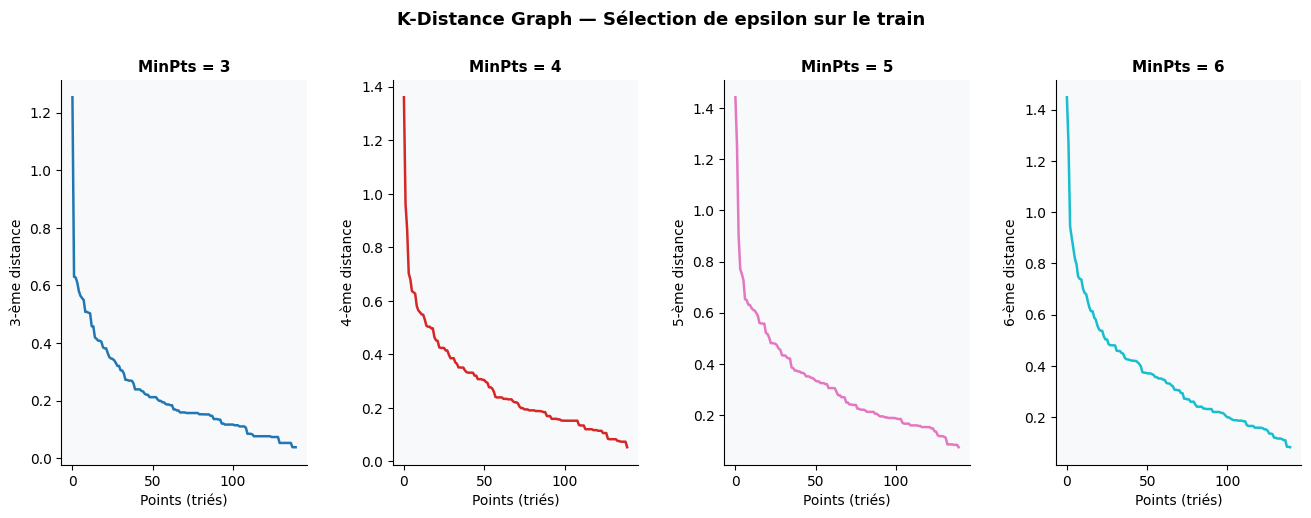

In [22]:
# Choix de epsilon via K-Distance Graph
min_samples_candidates = [3, 4, 5, 6]

print('=' * 55)
print('  SELECTION DE epsilon (K-Distance Graph)')
print('=' * 55)
print('  Règle : MinPts = 2 * nb_features = 4')
print('  On lit le coude sur la courbe k-distance triée du train')

fig = plt.figure(figsize=(16, 5))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)

colors_k = plt.cm.tab10(np.linspace(0, 1, 4))

for idx, k in enumerate(min_samples_candidates):
    nbrs = NearestNeighbors(n_neighbors=k).fit(X_train_scaled)
    distances, _ = nbrs.kneighbors(X_train_scaled)
    k_distances = np.sort(distances[:, k - 1])[::-1]

    ax = fig.add_subplot(gs[0, idx])
    ax.plot(k_distances, color=colors_k[idx], linewidth=1.8)
    ax.set_title(f'MinPts = {k}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Points (triés)')
    ax.set_ylabel(f'{k}-ème distance')
    ax.set_facecolor('#f8f9fa')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('K-Distance Graph — Sélection de epsilon sur le train', fontsize=13, fontweight='bold', y=1.02)
plt.show();

In [30]:
# Hyperparameter tuning DBSCAN avec repeated holdout (sur train+val)
eps_candidates = np.round(np.arange(0.20, 1.01, 0.05), 2).tolist()
min_samples_grid = [3, 4, 5, 6]
n_repeats = 20
val_ratio_inner = 0.20

X_dev = X_trainval.copy()
results_tuning = []

print('=' * 78)
print('  HYPERPARAMETER TUNING - DBSCAN (Repeated Holdout sur train+val)')
print('=' * 78)
print(f'  Configurations testees : {len(eps_candidates) * len(min_samples_grid)}')
print(f'  Repetitions aleatoires : {n_repeats}\n')

for eps in eps_candidates:
    for min_samples in min_samples_grid:
        train_sils, val_sils = [], []
        train_clusters, val_clusters = [], []
        val_noises = []

        for rep in range(n_repeats):
            X_inner_train, X_inner_val = train_test_split(
                X_dev, test_size=val_ratio_inner, random_state=2026 + rep, shuffle=True
            )
            scaler_inner = StandardScaler()
            X_inner_train_scaled = scaler_inner.fit_transform(X_inner_train)
            X_inner_val_scaled = scaler_inner.transform(X_inner_val)

            labels_train = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_inner_train_scaled)
            n_clusters_train = len(set(labels_train)) - (1 if -1 in labels_train else 0)
            mask_train = labels_train != -1
            sil_train = silhouette_score(X_inner_train_scaled[mask_train], labels_train[mask_train]) if n_clusters_train > 1 and mask_train.sum() > 2 else -1.0

            labels_val = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_inner_val_scaled)
            n_clusters_val = len(set(labels_val)) - (1 if -1 in labels_val else 0)
            n_noise_val = int(np.sum(labels_val == -1))
            mask_val = labels_val != -1
            sil_val = silhouette_score(X_inner_val_scaled[mask_val], labels_val[mask_val]) if n_clusters_val > 1 and mask_val.sum() > 2 else -1.0

            train_sils.append(sil_train)
            val_sils.append(sil_val)
            train_clusters.append(n_clusters_train)
            val_clusters.append(n_clusters_val)
            val_noises.append(n_noise_val / len(X_inner_val_scaled))

        mean_train_sil = float(np.mean(train_sils))
        mean_val_sil = float(np.mean(val_sils))
        std_val_sil = float(np.std(val_sils))
        mean_train_clusters = float(np.mean(train_clusters))
        mean_val_clusters = float(np.mean(val_clusters))
        mean_val_noise_ratio = float(np.mean(val_noises))
        combined_score = 0.30 * mean_train_sil + 0.60 * mean_val_sil - 0.10 * mean_val_noise_ratio

        results_tuning.append({
            'eps': eps,
            'min_samples': min_samples,
            'mean_train_silhouette': mean_train_sil,
            'mean_val_silhouette': mean_val_sil,
            'std_val_silhouette': std_val_sil,
            'mean_train_clusters': mean_train_clusters,
            'mean_val_clusters': mean_val_clusters,
            'mean_val_noise_ratio': mean_val_noise_ratio,
            'combined_score': combined_score
        })

valid = [r for r in results_tuning if r['mean_val_silhouette'] > 0 and r['mean_val_clusters'] > 1]
best_config = max(valid, key=lambda r: r['combined_score'])
best_eps = best_config['eps']
best_min_samples = best_config['min_samples']

print('\n' + '=' * 78)
print('  MEILLEURE CONFIGURATION (selection sur validation moyenne)')
print('=' * 78)
print(f'  eps                    : {best_config["eps"]}')
print(f'  min_samples            : {best_config["min_samples"]}')
print(f'  mean train silhouette  : {best_config["mean_train_silhouette"]:.4f}')
print(f'  mean val silhouette    : {best_config["mean_val_silhouette"]:.4f}')
print(f'  std val silhouette     : {best_config["std_val_silhouette"]:.4f}')
print(f'  mean train clusters    : {best_config["mean_train_clusters"]:.2f}')
print(f'  mean val clusters      : {best_config["mean_val_clusters"]:.2f}')
print(f'  mean val noise ratio   : {best_config["mean_val_noise_ratio"]:.2%}')
print(f'  combined score         : {best_config["combined_score"]:.4f}')

  HYPERPARAMETER TUNING - DBSCAN (Repeated Holdout sur train+val)
  Configurations testees : 68
  Repetitions aleatoires : 20


  MEILLEURE CONFIGURATION (selection sur validation moyenne)
  eps                    : 0.4
  min_samples            : 3
  mean train silhouette  : 0.4703
  mean val silhouette    : 0.5750
  std val silhouette     : 0.3680
  mean train clusters    : 5.20
  mean val clusters      : 3.15
  mean val noise ratio   : 39.56%
  combined score         : 0.4465


In [31]:
# Evaluation finale unique sur test (apres selection hyperparametres)
scaler_final = StandardScaler()
X_trainval_scaled_final = scaler_final.fit_transform(X_trainval)
X_test_scaled_final = scaler_final.transform(X_test)

labels_trainval_final = DBSCAN(eps=best_eps, min_samples=best_min_samples).fit_predict(X_trainval_scaled_final)
n_clusters_trainval_final = len(set(labels_trainval_final)) - (1 if -1 in labels_trainval_final else 0)
n_noise_trainval_final = int(np.sum(labels_trainval_final == -1))

labels_test = DBSCAN(eps=best_eps, min_samples=best_min_samples).fit_predict(X_test_scaled_final)
n_clusters_test = len(set(labels_test)) - (1 if -1 in labels_test else 0)
n_noise_test = int(np.sum(labels_test == -1))
mask_test = labels_test != -1
sil_test = silhouette_score(X_test_scaled_final[mask_test], labels_test[mask_test]) if n_clusters_test > 1 and mask_test.sum() > 2 else -1.0

print('=' * 72)
print('  EVALUATION FINALE (TEST UNIQUE - NON UTILISE AU TUNING)')
print('=' * 72)
print(f'  eps                       : {best_eps}')
print(f'  min_samples               : {best_min_samples}')
print(f'  Clusters (train+val final): {n_clusters_trainval_final}')
print(f'  Bruit (train+val final)   : {n_noise_trainval_final}')
print(f'  Clusters (test)           : {n_clusters_test}')
print(f'  Bruit (test)              : {n_noise_test}')
print(f'  Silhouette (test)         : {sil_test:.4f}')

  EVALUATION FINALE (TEST UNIQUE - NON UTILISE AU TUNING)
  eps                       : 0.4
  min_samples               : 3
  Clusters (train+val final): 5
  Bruit (train+val final)   : 12
  Clusters (test)           : 2
  Bruit (test)              : 13
  Silhouette (test)         : 0.7390


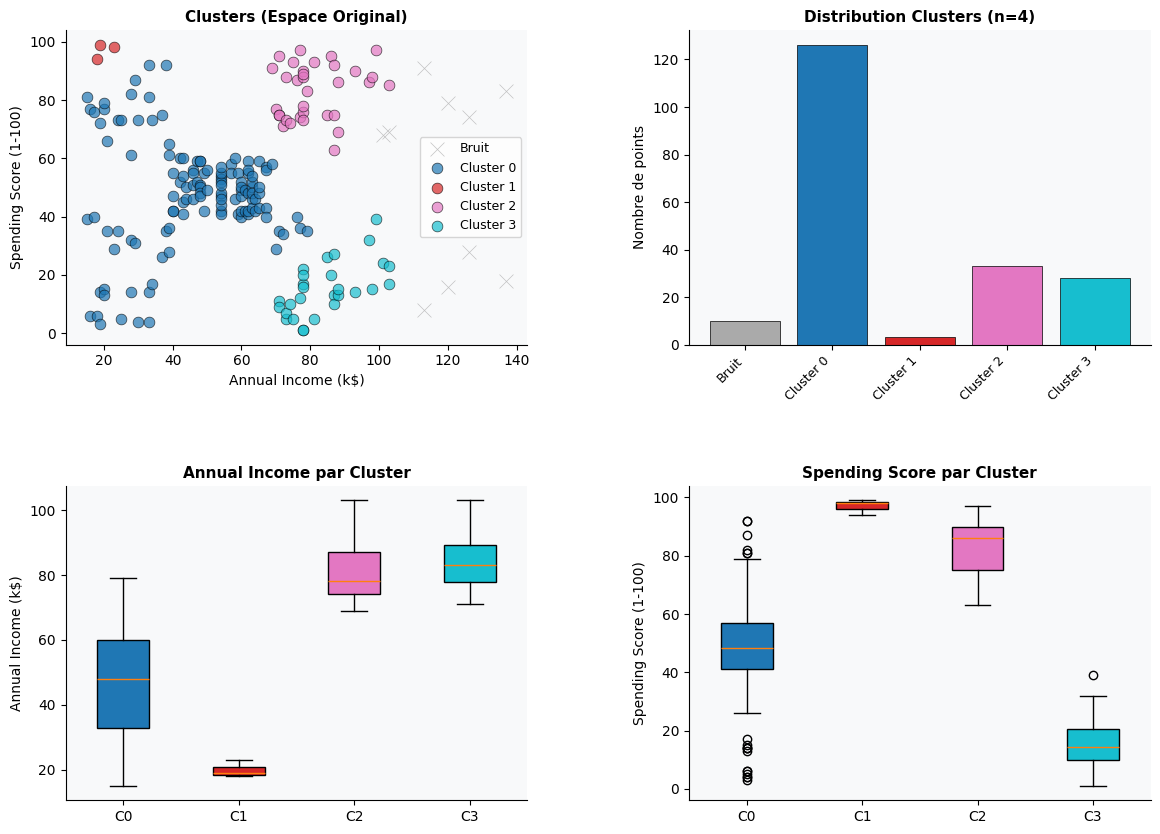

In [33]:
# Visualisation finale (sans la 1ere et la derniere image)
scaler_vis = StandardScaler()
X_scaled = scaler_vis.fit_transform(X)
labels = DBSCAN(eps=best_eps, min_samples=best_min_samples).fit_predict(X_scaled)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
unique_labels = sorted(set(labels))
colors_clusters = plt.cm.tab10(np.linspace(0, 1, max(n_clusters, 1)))

def get_color(label):
    if label == -1:
        return '#aaaaaa'
    return colors_clusters[label % len(colors_clusters)]

fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# 1) Clusters (espace original)
ax1 = fig.add_subplot(gs[0, 0])
for label in unique_labels:
    mask = labels == label
    marker = 'o' if label != -1 else 'x'
    size = 60 if label != -1 else 100
    ax1.scatter(X[mask, 0], X[mask, 1], c=[get_color(label)], 
                label=f'Cluster {label}' if label != -1 else 'Bruit', 
                marker=marker, s=size, alpha=0.7, edgecolors='black', linewidth=0.5)
ax1.set_title('Clusters (Espace Original)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Annual Income (k$)')
ax1.set_ylabel('Spending Score (1-100)')
ax1.set_facecolor('#f8f9fa')
ax1.legend(loc='best', fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

# 2) Distribution des labels
ax2 = fig.add_subplot(gs[0, 1])
unique_l, counts_l = np.unique(labels, return_counts=True)
colors_l = [get_color(int(l)) for l in unique_l]
bar_labels = [f'Cluster {int(l)}' if l != -1 else 'Bruit' for l in unique_l]
ax2.bar(range(len(unique_l)), counts_l, color=colors_l, edgecolor='black', linewidth=0.5)
ax2.set_xticks(range(len(unique_l)))
ax2.set_xticklabels(bar_labels, rotation=45, ha='right', fontsize=9)
ax2.set_title(f'Distribution Clusters (n={n_clusters})', fontsize=11, fontweight='bold')
ax2.set_ylabel('Nombre de points')
ax2.set_facecolor('#f8f9fa')
ax2.spines[['top', 'right']].set_visible(False)

# 3) Boxplot Annual Income by Cluster
ax3 = fig.add_subplot(gs[1, 0])
data_income = [X[labels == label, 0] for label in unique_labels if label != -1]
if len(data_income) > 0:
    bp1 = ax3.boxplot(data_income, labels=[f'C{int(l)}' for l in unique_labels if l != -1], patch_artist=True)
    for patch, label in zip(bp1['boxes'], [l for l in unique_labels if l != -1]):
        patch.set_facecolor(get_color(label))
ax3.set_title('Annual Income par Cluster', fontsize=11, fontweight='bold')
ax3.set_ylabel('Annual Income (k$)')
ax3.set_facecolor('#f8f9fa')
ax3.spines[['top', 'right']].set_visible(False)

# 4) Boxplot Spending Score by Cluster
ax4 = fig.add_subplot(gs[1, 1])
data_score = [X[labels == label, 1] for label in unique_labels if label != -1]
if len(data_score) > 0:
    bp2 = ax4.boxplot(data_score, labels=[f'C{int(l)}' for l in unique_labels if l != -1], patch_artist=True)
    for patch, label in zip(bp2['boxes'], [l for l in unique_labels if l != -1]):
        patch.set_facecolor(get_color(label))
ax4.set_title('Spending Score par Cluster', fontsize=11, fontweight='bold')
ax4.set_ylabel('Spending Score (1-100)')
ax4.set_facecolor('#f8f9fa')
ax4.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()